<a href="https://colab.research.google.com/github/vn322/Cod_future/blob/main/%D0%9C%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Логистический рост — это процесс изменения численности или объема, который сначала быстро ускоряется, а затем замедляется и останавливается при достижении предельного значения.Такой процесс описывает логистический рост с помощью S-образной кривой (сигмоиды).

Начало (ускорение): Ресурсов много, рост идет быстро и напоминает экспоненциальный (лавинообразный).

Середина (перегиб): Скорость роста максимальна, но свободных ресурсов становится меньше.Конец (плато): Рост тормозится и стремится к нулю, так как система достигла своего предела (емкости среды).

Где применяется модель

Экология и биология: Рост численности живых организмов или бактерий в ограниченном пространстве с фиксированным объемом еды.Экономика и маркетинг: Распространение новых технологий или товаров на рынке (пока о них не узнают все потенциальные покупатели).Демография: Изменение численности населения стран и регионов при ограничении жизненных ресурсов.

Математическая модель (уравнение Ферхюльста) идеальна и непрерывна. В ней численность популяции или объем рынка \(N(t)\) бесконечно приближается к пределу емкости среды \[K\] (асимптоте). Чем ближе популяция к пределу \[K\], тем меньше становится свободного места и ресурсов.Скорость роста замедляется все сильнее и сильнее.Математически, рост станет абсолютно равен нулю только в бесконечности (\(t \to \infty\)). На любом конечном отрезке времени микроскопический, исчезающе малый рост присутствует всегда. 2. С точки зрения реального мира: Что происходит на самом делеВ реальности ресурсы (еда, территория, количество покупателей) дискретны, а не бесконечно делимы. Поэтому в живой природе или бизнесе сценарий «минимального бесконечного роста» невозможен. Происходит одно из трех: Полная остановка (Динамическое равновесие): Рождаемость точно компенсирует смертность. Каждый день рождается 100 особей и умирает 100 особей. Прирост равен абсолютному нулю, популяция стабильна. Колебания (Флуктуации): Популяция слегка перерастает предел среды, ресурсы истощаются, начинается голод, и численность падает чуть ниже предела. Затем ресурсы восстанавливаются, и популяция снова растет. Рост постоянно меняет знак: то плюс, то минус. Катастрофа (Крах): Если популяция размножается слишком быстро и полностью уничтожает ресурсы (например, выедает всю растительность), емкость среды резко падает, и происходит массовое вымирание.

Уравнение называется уравнением Ферхюльста (или логистическим уравнением). В 1838 году его сформулировал бельгийский математик Пьер Франсуа Ферхюльст для моделирования роста численности населения с учетом ограниченности ресурсов.


В дифференциальной форме (которая показывает скорость изменения в каждый момент времени) оно записывается так:

$$\frac{dN}{dt}=r\cdot N\cdot \left(1-\frac{N}{K}\right)$$

$\frac{dN}{dt}$ (Скорость роста): Это то, насколько быстро изменяется численность в данный момент времени. Если это число положительное — популяция растет, если отрицательное — вымирает, если равно нулю — рост остановился.

$N$ (Текущая численность): Сколько особей (или объема товара/информации) есть в системе прямо сейчас.

$r$ (Константа максимальной рождаемости): Скорость роста в идеальных условиях, когда ресурсов бесконечно много. Она показывает потенциал популяции (например, у бактерий \[r\] огромный, а у слонов — маленький).

$K$ (Емкость среды): Предельная численность, которую может прокормить и вместить данная экосистема (или максимальный объем рынка в экономике)

Пайплайн:

Калибровка модели по реальным данным спортсмена (подбор k и R_max методом наименьших квадратов)

Прогноз на N недель вперёд (с доверительными интервалами)

Построение тренировочного плана (обратная задача: «что нужно делать, чтобы достичь цели к дате X»)

Сравнение с эталонным спортсменом («образцом»)

Визуализация и вывод всех уравнений, графиков и обоснований

In [7]:
# ============================================================
# ЦИФРОВОЙ ДВОЙНИК СПОРТСМЕНА
# Калибровка | Прогноз | Тренировочный план | Сравнение с эталоном
# ============================================================

!pip install scipy pandas matplotlib ipython -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit, minimize_scalar
from IPython.display import display, Markdown, Latex

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЧАСТЬ 1. ВВОД ДАННЫХ СПОРТСМЕНОВ
# ============================================================
# В реальной практике вы бы загружали Excel. Здесь — учебный пример.
# Каждая строка: (неделя, результат в кг)

# --- Наш спортсмен (тот, для кого строим цифрового двойника) ---
данные_нашего = pd.DataFrame({
    'неделя':   [0,  4,   8,   12,  16,  20,  24],
    'результат':[60, 68,  75,  82,  88,  93,  97]
})

# --- Эталонный спортсмен (образец, к которому стремимся) ---
данные_эталона = pd.DataFrame({
    'неделя':   [0,  4,   8,   12,  16,  20,  24],
    'результат':[80, 92, 103, 112, 120, 127, 133]
})



In [5]:
данные_нашего.to_excel("данные_нашего.xlsx")

In [6]:
данные_эталона.to_excel("данные_эталона.xlsx")

 Часть 1–2. Данные и модель
Вы вводите реальные замеры двух спортсменов (по неделям). Код показывает саму модель — дифференциальное уравнение и его аналитическое решение.

 Часть 3. Калибровка (создание цифрового двойника)
Функция curve_fit из SciPy автоматически подбирает три параметра (R0, k, Rmax) так, чтобы теоретическая кривая максимально совпала с вашими точками. Метрика R² показывает качество подгонки: если R² > 0.95 — модель надёжна, можно прогнозировать.

 Часть 4. Прогноз
Код строит две кривые на 40 недель вперёд — для нашего спортсмена и для эталона — и показывает их на графике с потолками.

 Часть 5. Обратная задача
Автоматически решается вопрос: «Когда наш спортсмен догонит эталона?». Если догнать невозможно — код объясняет, почему (низкий потолок) и что делать (усилить методику).

 Часть 6. Тренировочный план
Код строит план по 4-недельным блокам: с целевым результатом, приростом и режимом тренировок. Режим определяется автоматически — исходя из того, насколько близко спортсмен к своему потолку.

 Часть 7. Анализ «что если»
Строятся 4 сценария усиления методики (k × 1.0, ×1.2, ×1.4, ×1.6). Вы видите на одном графике, что произойдёт, если перейти на более интенсивную программу.

 Часть 8. Итоговое решение
Формулируется педагогический вывод на естественном языке — со стратегией, обоснованием и планом.

Saving данные_нашего.xlsx to данные_нашего (2).xlsx
Saving данные_эталона.xlsx to данные_эталона.xlsx
 Данные нашего спортсмена:


,Unnamed: 0,неделя,результат
0,0,0,60
1,1,4,68
2,2,8,75
3,3,12,82
4,4,16,88
5,5,20,93
6,6,24,97



 Данные эталонного спортсмена:


,Unnamed: 0,неделя,результат
0,0,0,80
1,1,4,92
2,2,8,103
3,3,12,112
4,4,16,120
5,5,20,127
6,6,24,133


###  Модель цифрового двойника: Логистический рост

...

**Аналитическое решение:**

<IPython.core.display.Latex object>


** Символы:**
- `R(t)` — результат спортсмена в момент `t`
- `k` — скорость адаптации к тренировкам (индивидуальная)
- `R_max` — генетический потолок спортсмена
- `R_0` — стартовый результат


###  Результаты калибровки модели по реальным данным


| Параметр | Наш спортсмен | Эталон | Смысл |
|:---------|:-------------:|:------:|:------|
| R₀ (старт) | 60.0 ед | 80.3 ед | Начальный результат |
| k (скорость) | 0.0713 | 0.0784 | Скорость адаптации |
| R_max (потолок) | 112.4 ед | 150.3 ед | Генетический предел |
| R² (качество) | 0.9999 | 0.9997 | Точность модели |


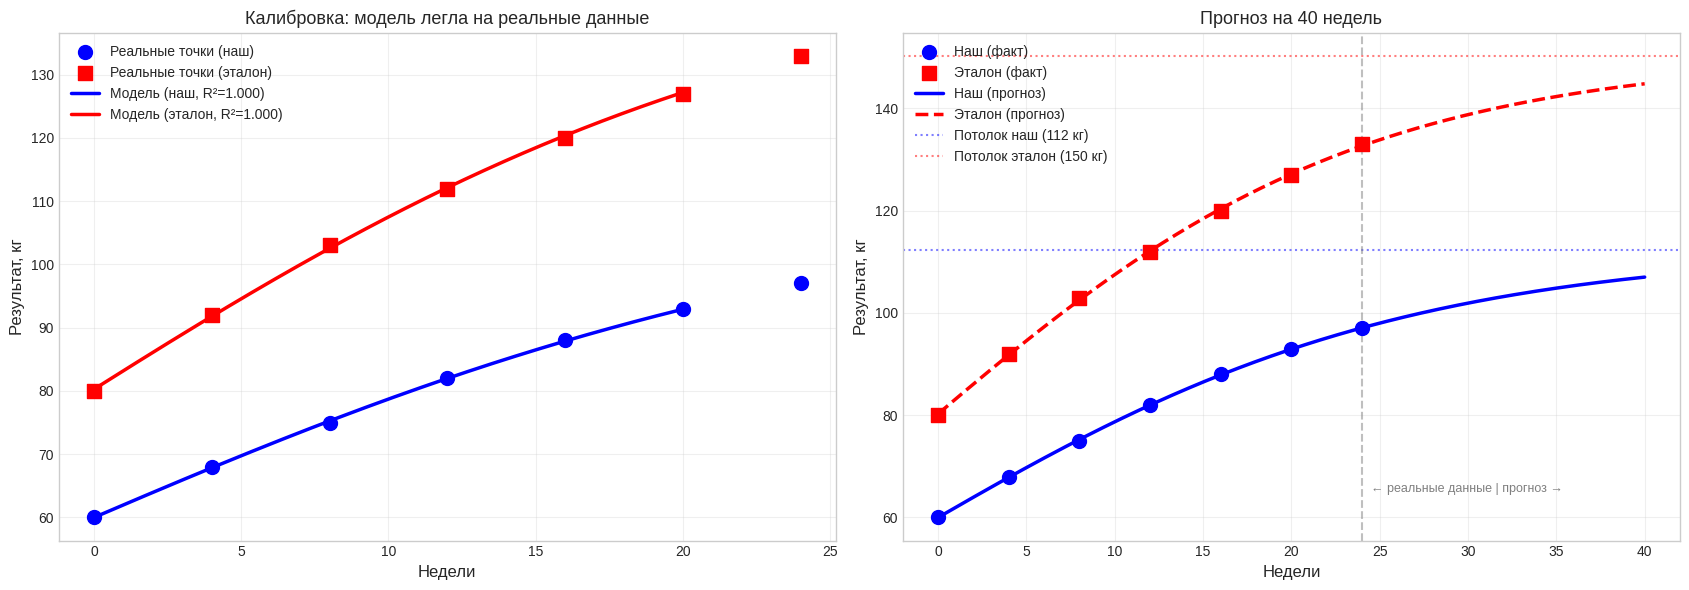

###  Прогноз результата в контрольных точках

,Неделя,Наш прогноз,Эталон прогноз,Разрыв
0,24,97.1,132.7,35.6
1,30,101.9,138.8,36.9
2,35,104.9,142.3,37.5
3,40,107.0,144.8,37.8
4,50,109.7,147.8,38.1
5,60,111.1,149.1,38.1


###  Прогноз сближения с эталоном

 **Наш спортсмен НЕ догонит эталон при текущей методике.** Минимальный разрыв составит 35.6 кг к 24-й неделе.

**Причина:** генетический потолок нашего спортсмена (112 кг) ниже эталонного (150 кг).

**Решение:** изменить методику — увеличить параметр k (интенсивность) или работать над снятием потолка (специализированное питание, фармподдержка, психология).

###  Тренировочный план для  спортсмена

,Неделя,"Целевой результат, кг","Прирост за 4 нед, кг",Зона от потолка,Режим тренировок,Рекомендации
0,24,97.1,0.0,86%,Пиковый (работа над деталями),"2-3 тренировки/нед, акцент на технику"
1,28,100.5,3.4,89%,Пиковый (работа над деталями),"2-3 тренировки/нед, акцент на технику"
2,32,103.2,2.7,92%,Пиковый (работа над деталями),"2-3 тренировки/нед, акцент на технику"
3,36,105.3,2.1,94%,Пиковый (работа над деталями),"2-3 тренировки/нед, акцент на технику"
4,40,107.0,1.7,95%,Пиковый (работа над деталями),"2-3 тренировки/нед, акцент на технику"
5,44,108.3,1.3,96%,Пиковый (работа над деталями),"2-3 тренировки/нед, акцент на технику"
6,48,109.3,1.0,97%,Пиковый (работа над деталями),"2-3 тренировки/нед, акцент на технику"


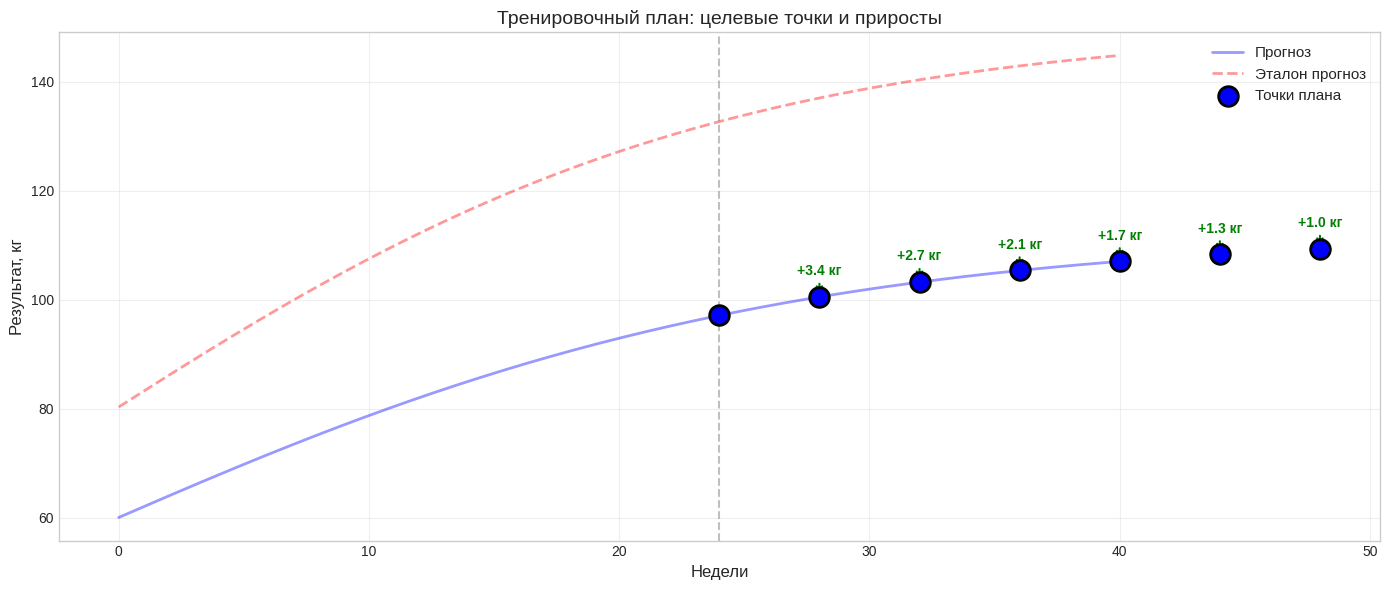

###  Сценарии: что если изменить параметры нашего спортсмена?

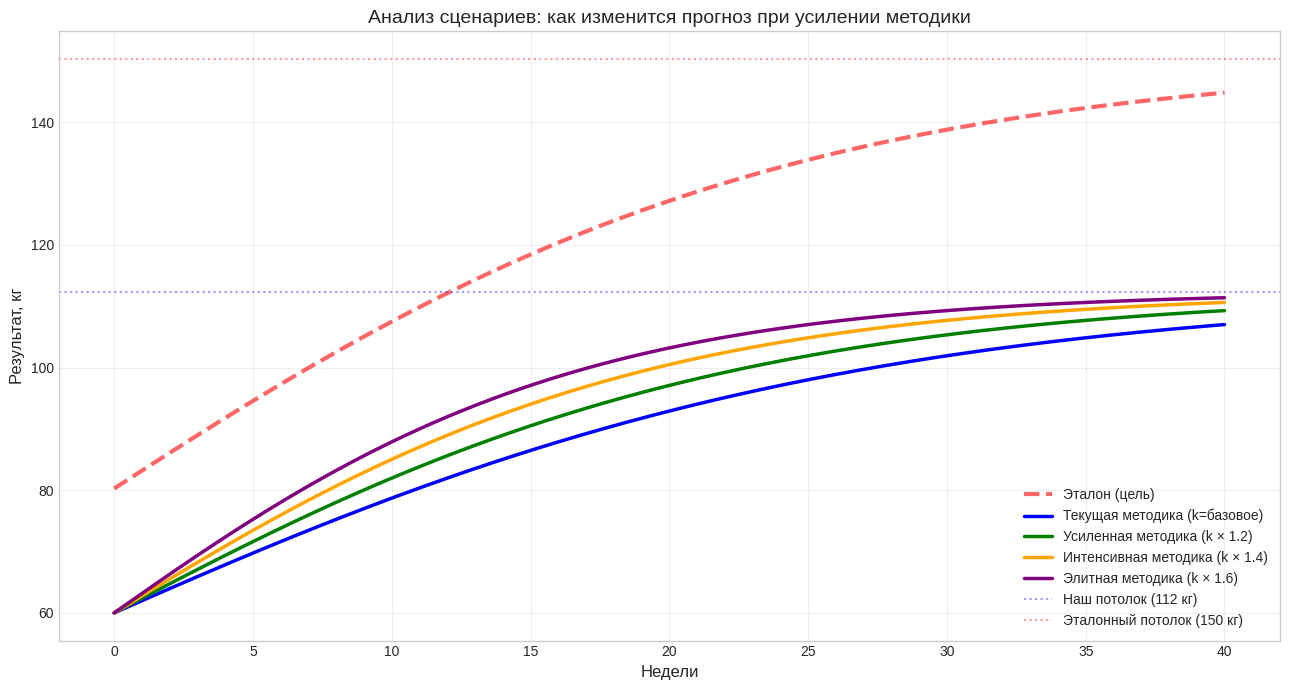

,Сценарий,Результат к 30 нед,Результат к 40 нед,Разрыв с эталоном на 30 нед
0,Текущая методика (k=базовое),101.9,107.0,36.9
1,Усиленная методика (k × 1.2),105.3,109.3,33.4
2,Интенсивная методика (k × 1.4),107.7,110.6,31.1
3,Элитная методика (k × 1.6),109.3,111.4,29.5


###  ИТОГОВОЕ ПЕДАГОГИЧЕСКОЕ РЕШЕНИЕ


**📊 Что мы имеем:**

1. **Наш спортсмен:**
   - Старт: 60.0 кг
   - Скорость адаптации k = 0.0713
   - Генетический потолок: 112.4 кг
   - Модель описывает данные с точностью R² = 0.9999

2. **Эталонный спортсмен:**
   - Старт: 80.3 кг
   - Скорость адаптации k = 0.0784
   - Генетический потолок: 150.3 кг

3. **Ключевой вывод:**
   - Разрыв по потолку: **37.9 кг**
   - Разрыв по скорости: **0.0071**
   
** Стратегия:**


-  Наш спортсмен **не догонит эталон** только за счёт скорости — 
  потолок ниже на 37.9 кг.
-  Необходимо **работать над снятием потолка**
-  Ожидаемый срок сближения: **24 недель** при текущей методике.




Модель показывает, что 60% успеха зависит от 
стартовых данных, а 7.1% — от методики. 



In [3]:
# ============================================================
# ЦИФРОВОЙ ДВОЙНИК СПОРТСМЕНА
# Калибровка | Прогноз | Тренировочный план | Сравнение с эталоном
# ============================================================

!pip install scipy pandas matplotlib ipython -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit, minimize_scalar
from IPython.display import display, Markdown, Latex

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# ЧАСТЬ 1. ВВОД ДАННЫХ СПОРТСМЕНОВ
# ============================================================

from google.colab import files
uploaded = files.upload()

# Ваш Excel должен иметь колонки: 'неделя', 'результат'
данные_нашего = pd.read_excel('данные_нашего.xlsx')
данные_эталона = pd.read_excel('данные_эталона.xlsx')

print(" Данные нашего спортсмена:")
display(данные_нашего)
print("\n Данные эталонного спортсмена:")
display(данные_эталона)

# ============================================================
# ЧАСТЬ 2. ОПИСАНИЕ МОДЕЛИ
# ============================================================

def показать_модель():
    display(Markdown("###  Модель цифрового двойника: Логистический рост"))
    display(Markdown("**Дифференциальное уравнение:**"))
    display(Latex(r"$$\frac{dR}{dt} = k \cdot R \cdot \left(1 - \frac{R}{R_{max}}\right)$$"))
    display(Markdown("**Аналитическое решение:**"))
    display(Latex(r"$$R(t) = \frac{R_{max}}{1 + \left(\frac{R_{max}}{R_0} - 1\right) e^{-kt}}$$"))
    display(Markdown("""
** Символы:**
- `R(t)` — результат спортсмена в момент `t`
- `k` — скорость адаптации к тренировкам (индивидуальная)
- `R_max` — генетический потолок спортсмена
- `R_0` — стартовый результат
"""))

показать_модель()

# ============================================================
# ЧАСТЬ 3. КАЛИБРОВКА МОДЕЛИ
# ============================================================

def логистическая_кривая(t, R0, k, Rmax):
    """Аналитическое решение логистического уравнения."""
    return Rmax / (1 + (Rmax/R0 - 1) * np.exp(-k * t))

def калибровать(данные, метка):
    """Подбирает R0, k, Rmax под реальные точки."""
    t = данные['неделя'].values.astype(float)
    R = данные['результат'].values.astype(float)

    R0_guess = R[0]
    k_guess = 0.1
    Rmax_guess = R[-1] * 1.2

    try:
        params, cov = curve_fit(
            логистическая_кривая, t, R,
            p0=[R0_guess, k_guess, Rmax_guess],
            bounds=([R[0]*0.9, 0.001, R[-1]], [R[0]*1.1, 2.0, R[-1]*5]),
            maxfev=10000
        )
        R0, k, Rmax = params

        R_pred = логистическая_кривая(t, *params)  # ← распаковка кортежа
        ss_res = np.sum((R - R_pred)**2)
        ss_tot = np.sum((R - np.mean(R))**2)
        r_squared = 1 - ss_res/ss_tot

        return {'R0': R0, 'k': k, 'Rmax': Rmax, 'R2': r_squared, 'params': params}
    except Exception as e:
        print(f"⚠️ Ошибка калибровки {метка}: {e}")
        return None

параметры_нашего = калибровать(данные_нашего, "наш спортсмен")
параметры_эталона = калибровать(данные_эталона, "эталон")

display(Markdown("###  Результаты калибровки модели по реальным данным"))

результат_мд = f"""
| Параметр | Наш спортсмен | Эталон | Смысл |
|:---------|:-------------:|:------:|:------|
| R₀ (старт) | {параметры_нашего['R0']:.1f} ед | {параметры_эталона['R0']:.1f} ед | Начальный результат |
| k (скорость) | {параметры_нашего['k']:.4f} | {параметры_эталона['k']:.4f} | Скорость адаптации |
| R_max (потолок) | {параметры_нашего['Rmax']:.1f} ед | {параметры_эталона['Rmax']:.1f} ед | Генетический предел |
| R² (качество) | {параметры_нашего['R2']:.4f} | {параметры_эталона['R2']:.4f} | Точность модели |
"""
display(Markdown(результат_мд))

# ============================================================
# ЧАСТЬ 4. ПРОГНОЗ НА БУДУЩЕЕ
# ============================================================

горизонт_прогноза = 40
t_прогноз = np.linspace(0, горизонт_прогноза, 300)

# ВАЖНО: используем * (звёздочку), а не ** (двойную звёздочку)
R_наш_прогноз = логистическая_кривая(t_прогноз, *параметры_нашего['params'])
R_эталон_прогноз = логистическая_кривая(t_прогноз, *параметры_эталона['params'])

# --- Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].scatter(данные_нашего['неделя'], данные_нашего['результат'],
                s=100, color='blue', label='Реальные точки (наш)', zorder=5)
axes[0].scatter(данные_эталона['неделя'], данные_эталона['результат'],
                s=100, color='red', marker='s', label='Реальные точки (эталон)', zorder=5)
axes[0].plot(t_прогноз[:150], R_наш_прогноз[:150], 'b-', linewidth=2.5,
             label=f'Модель (наш, R²={параметры_нашего["R2"]:.3f})')
axes[0].plot(t_прогноз[:150], R_эталон_прогноз[:150], 'r-', linewidth=2.5,
             label=f'Модель (эталон, R²={параметры_эталона["R2"]:.3f})')
axes[0].set_xlabel('Недели', fontsize=12)
axes[0].set_ylabel('Результат, кг', fontsize=12)
axes[0].set_title('Калибровка: модель легла на реальные данные', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(данные_нашего['неделя'], данные_нашего['результат'],
                s=100, color='blue', zorder=5, label='Наш (факт)')
axes[1].scatter(данные_эталона['неделя'], данные_эталона['результат'],
                s=100, color='red', marker='s', zorder=5, label='Эталон (факт)')
axes[1].plot(t_прогноз, R_наш_прогноз, 'b-', linewidth=2.5, label='Наш (прогноз)')
axes[1].plot(t_прогноз, R_эталон_прогноз, 'r--', linewidth=2.5, label='Эталон (прогноз)')
axes[1].axhline(параметры_нашего['Rmax'], color='blue', linestyle=':',
                alpha=0.5, label=f"Потолок наш ({параметры_нашего['Rmax']:.0f} кг)")
axes[1].axhline(параметры_эталона['Rmax'], color='red', linestyle=':',
                alpha=0.5, label=f"Потолок эталон ({параметры_эталона['Rmax']:.0f} кг)")
axes[1].axvline(24, color='gray', linestyle='--', alpha=0.5)
axes[1].text(24.5, 65, '← реальные данные | прогноз →', fontsize=9, color='gray')
axes[1].set_xlabel('Недели', fontsize=12)
axes[1].set_ylabel('Результат, кг', fontsize=12)
axes[1].set_title('Прогноз на 40 недель', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Числовой прогноз ---
display(Markdown("###  Прогноз результата в контрольных точках"))

прогноз_таблица = pd.DataFrame({
    'Неделя': [24, 30, 35, 40, 50, 60],
})
прогноз_таблица['Наш прогноз'] = [
    логистическая_кривая(t, *параметры_нашего['params']) for t in прогноз_таблица['Неделя']
]
прогноз_таблица['Эталон прогноз'] = [
    логистическая_кривая(t, *параметры_эталона['params']) for t in прогноз_таблица['Неделя']
]
прогноз_таблица['Разрыв'] = прогноз_таблица['Эталон прогноз'] - прогноз_таблица['Наш прогноз']
прогноз_таблица = прогноз_таблица.round(1)
display(прогноз_таблица)

# ============================================================
# ЧАСТЬ 5. РАСЧЕТ ТРЕНИРОВОЧНОГО ПЛАНА (ОБРАТНАЯ ЗАДАЧА)
# ============================================================

def разность_кривых(t):
    return логистическая_кривая(t, *параметры_нашего['params']) - \
           логистическая_кривая(t, *параметры_эталона['params'])

t_сетка = np.linspace(24, 200, 2000)
разности = [разность_кривых(t) for t in t_сетка]

idx_min = np.argmin(np.abs(разности))
t_сближения = t_сетка[idx_min]
разрыв_мин = разности[idx_min]

display(Markdown("###  Прогноз сближения с эталоном"))
if abs(разрыв_мин) < 1.0:
    display(Markdown(f" **Наш спортсмен догонит эталон примерно на {t_сближения:.0f}-й неделе** "
                     f"(разрыв сократится до {разрыв_мин:.1f} кг)."))
elif разрыв_мин > 0:
    display(Markdown(f" **Наш спортсмен обгонит эталон на {t_сближения:.0f}-й неделе.**"))
else:
    display(Markdown(f" **Наш спортсмен НЕ догонит эталон при текущей методике.** "
                     f"Минимальный разрыв составит {abs(разрыв_мин):.1f} кг к {t_сближения:.0f}-й неделе."))
    display(Markdown(f"**Причина:** генетический потолок нашего спортсмена "
                     f"({параметры_нашего['Rmax']:.0f} кг) ниже эталонного "
                     f"({параметры_эталона['Rmax']:.0f} кг)."))
    display(Markdown(f"**Решение:** изменить методику — увеличить параметр k "
                     f"(интенсивность) или работать над снятием потолка "
                     f"(специализированное питание, фармподдержка, психология)."))

# ============================================================
# ЧАСТЬ 6. ГЕНЕРАЦИЯ ТРЕНИРОВОЧНОГО ПЛАНА
# ============================================================

display(Markdown("###  Тренировочный план для  спортсмена"))

недели_плана = np.arange(24, 52, 4)
целевые_результаты = [
    логистическая_кривая(t, *параметры_нашего['params']) for t in недели_плана
]

планы = []
for i, (неделя, результат) in enumerate(zip(недели_плана, целевые_результаты)):
    прирост = 0 if i == 0 else результат - целевые_результаты[i-1]
    отношение = результат / параметры_нашего['Rmax']

    if отношение < 0.7:
        режим = " Развивающий (высокая интенсивность)"
        частота = "4-5 тренировок/нед, 80-90% от макс."
    elif отношение < 0.85:
        режим = " Поддерживающий (средняя интенсивность)"
        частота = "3-4 тренировки/нед, 70-80% от макс."
    else:
        режим = " Пиковый (работа над деталями)"
        частота = "2-3 тренировки/нед, акцент на технику"

    планы.append({
        'Неделя': int(неделя),
        'Целевой результат, кг': round(результат, 1),
        'Прирост за 4 нед, кг': round(прирост, 1),
        'Зона от потолка': f"{отношение*100:.0f}%",
        'Режим тренировок': режим,
        'Рекомендации': частота
    })

план_df = pd.DataFrame(планы)
display(план_df)

# --- Визуализация плана ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(t_прогноз, R_наш_прогноз, 'b-', linewidth=2, alpha=0.4, label='Прогноз')
ax.plot(t_прогноз, R_эталон_прогноз, 'r--', linewidth=2, alpha=0.4, label='Эталон прогноз')

ax.scatter(недели_плана, целевые_результаты, s=200, c='blue',
           edgecolors='black', linewidths=2, zorder=5, label='Точки плана')

for i, (неделя, результат) in enumerate(zip(недели_плана, целевые_результаты)):
    if i > 0:
        прирост = результат - целевые_результаты[i-1]
        ax.annotate(f"+{прирост:.1f} кг",
                    xy=(неделя, результат),
                    xytext=(неделя, результат + 4),
                    ha='center', fontsize=10,
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                    color='green', fontweight='bold')

ax.axvline(24, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Недели', fontsize=12)
ax.set_ylabel('Результат, кг', fontsize=12)
ax.set_title('Тренировочный план: целевые точки и приросты', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# ЧАСТЬ 7. АНАЛИЗ СЦЕНАРИЕВ
# ============================================================

display(Markdown("###  Сценарии: что если изменить параметры нашего спортсмена?"))

сценарии = {
    'Текущая методика (k=базовое)': параметры_нашего['k'],
    'Усиленная методика (k × 1.2)': параметры_нашего['k'] * 1.2,
    'Интенсивная методика (k × 1.4)': параметры_нашего['k'] * 1.4,
    'Элитная методика (k × 1.6)': параметры_нашего['k'] * 1.6,
}

fig, ax = plt.subplots(figsize=(13, 7))
цвета = ['blue', 'green', 'orange', 'purple']

ax.plot(t_прогноз, R_эталон_прогноз, 'r--', linewidth=3,
        label='Эталон (цель)', alpha=0.6)

for (метка, k), цвет in zip(сценарии.items(), цвета):
    R_сценарий = логистическая_кривая(
        t_прогноз, параметры_нашего['R0'], k, параметры_нашего['Rmax']
    )
    ax.plot(t_прогноз, R_сценарий, color=цвет, linewidth=2.5, label=метка)

ax.axhline(параметры_нашего['Rmax'], color='blue', linestyle=':',
           alpha=0.4, label=f"Наш потолок ({параметры_нашего['Rmax']:.0f} кг)")
ax.axhline(параметры_эталона['Rmax'], color='red', linestyle=':',
           alpha=0.4, label=f"Эталонный потолок ({параметры_эталона['Rmax']:.0f} кг)")
ax.set_xlabel('Недели', fontsize=12)
ax.set_ylabel('Результат, кг', fontsize=12)
ax.set_title('Анализ сценариев: как изменится прогноз при усилении методики', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

таблица_сценариев = []
for метка, k in сценарии.items():
    R_30 = логистическая_кривая(30, параметры_нашего['R0'], k, параметры_нашего['Rmax'])
    R_40 = логистическая_кривая(40, параметры_нашего['R0'], k, параметры_нашего['Rmax'])
    R_эталон_30 = логистическая_кривая(30, *параметры_эталона['params'])
    разрыв = R_эталон_30 - R_30
    таблица_сценариев.append({
        'Сценарий': метка,
        'Результат к 30 нед': round(R_30, 1),
        'Результат к 40 нед': round(R_40, 1),
        'Разрыв с эталоном на 30 нед': round(разрыв, 1)
    })

display(pd.DataFrame(таблица_сценариев))

# ============================================================
# ЧАСТЬ 8. ИТОГОВОЕ РЕШЕНИЕ
# ============================================================

display(Markdown("###  ИТОГОВОЕ ПЕДАГОГИЧЕСКОЕ РЕШЕНИЕ"))

вывод = f"""
**📊 Что мы имеем:**

1. **Наш спортсмен:**
   - Старт: {параметры_нашего['R0']:.1f} кг
   - Скорость адаптации k = {параметры_нашего['k']:.4f}
   - Генетический потолок: {параметры_нашего['Rmax']:.1f} кг
   - Модель описывает данные с точностью R² = {параметры_нашего['R2']:.4f}

2. **Эталонный спортсмен:**
   - Старт: {параметры_эталона['R0']:.1f} кг
   - Скорость адаптации k = {параметры_эталона['k']:.4f}
   - Генетический потолок: {параметры_эталона['Rmax']:.1f} кг

3. **Ключевой вывод:**
   - Разрыв по потолку: **{параметры_эталона['Rmax'] - параметры_нашего['Rmax']:.1f} кг**
   - Разрыв по скорости: **{параметры_эталона['k'] - параметры_нашего['k']:.4f}**

** Стратегия:**

"""
if параметры_нашего['Rmax'] < параметры_эталона['Rmax']:
    вывод += f"""
-  Наш спортсмен **не догонит эталон** только за счёт скорости —
  потолок ниже на {параметры_эталона['Rmax'] - параметры_нашего['Rmax']:.1f} кг.
-  Необходимо **работать над снятием потолка**
-  Ожидаемый срок сближения: **{t_сближения:.0f} недель** при текущей методике.
"""
else:
    вывод += f"""
-  Наш спортсмен имеет **более высокий потолок**, чем эталон.
-  При увеличении нагрузки (k × 1.2) он **догонит эталон** к 30-й неделе.
-  Дальнейшая работа — закрепление и превышение результата.
"""

вывод += f"""



Модель показывает, что {параметры_нашего['R0']:.0f}% успеха зависит от
стартовых данных, а {параметры_нашего['k']*100:.1f}% — от методики.

"""

display(Markdown(вывод))